In [22]:
import tifffile as tiff
from tifffile import imwrite
import platform
system = platform.system()
import numpy as np
import matplotlib.pyplot as plt


import os
from skimage.filters import try_all_threshold, threshold_otsu,  threshold_triangle, threshold_yen, threshold_li


if system == 'Linux':
    home = '/home/'
elif system == 'Darwin':
    home = '/Users/'



Processing series 1---------------
Processing channel 0************************
treshold = 31
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_0/2026_05_26_s1_ch0_masks_triangle.tif


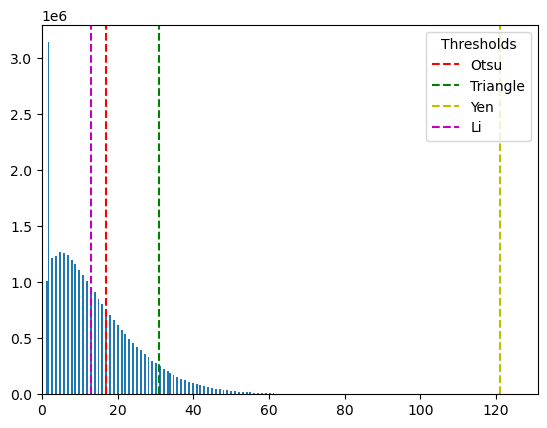

treshold = 29.156204223632812
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_0/2026_05_26_s1_ch0_deconv_iter_4_masks_triangle.tif


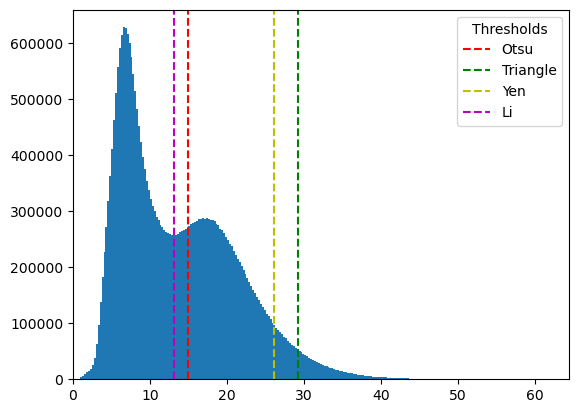

Processing channel 1************************
treshold = 3
saved /home/gerard/data/confocal/2026_05_26_Gerardo/series_1/channel_1/2026_05_26_s1_ch1_masks_triangle.tif


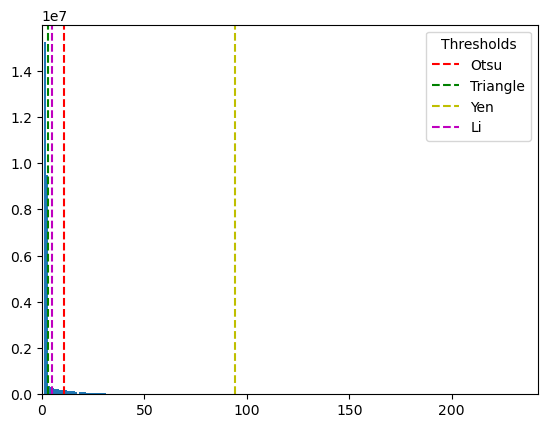

In [ ]:
treshold_algorithm_list =[
    'triangle',
   # 'otsu',
]

series_list = [
  #  0,
    1,
   # 2,
    
]


channel_list = [
   0,
   1,
   2,
    
]
deconv_iter_list = [
    # 1,
    # 2,
    # 3,
   4,
    # 5,
    # 6,
    # 7,
    

]
for series in series_list:
    print(f'Processing series {series}---------------')
    for channel in channel_list:
        print(f'Processing channel {channel}************************')
        for deconv_inter in deconv_iter_list:
        
            path_series_channel = f'gerard/data/confocal/2026_05_26_Gerardo/series_{series}/channel_{channel}'#gerard/data/confocal/2026_05_26_Gerardo/Project.lif'
            base = home + path_series_channel #os.path.join(home, )
            

            path_raw        = os.path.join(base, f'2026_05_26_s{series}_ch{channel}.tif')
            path_raw_masks  = os.path.join(base, f'2026_05_26_s{series}_ch{channel}_masks')
            path_deconv      = os.path.join(base, f'2026_05_26_s{series}_ch{channel}_deconv_iter_{deconv_inter}.tif')
            path_deconv_masks= os.path.join(base, f'2026_05_26_s{series}_ch{channel}_deconv_iter_{deconv_inter}_masks')

            for path_in, path_out in [(path_raw, path_raw_masks), (path_deconv, path_deconv_masks)]:
                with tiff.TiffFile(path_in) as tf:
                    stack = tf.asarray()
                    vxy = 1.0 / (tf.pages[0].tags['XResolution'].value[0] / tf.pages[0].tags['XResolution'].value[1])
                    vz  = tf.imagej_metadata['spacing']

                
                
                for treshold_algorithm in treshold_algorithm_list:
                    if treshold_algorithm == 'triangle':
                        thresh = threshold_triangle(stack)
                    elif treshold_algorithm == 'otsu':
                        thresh = threshold_otsu(stack)

                    # calculate several thresholds to plot:
                    stack_flat = stack[stack > 0]
                    otsu = threshold_otsu(stack)
                    triangle = threshold_triangle(stack)
                    yen = threshold_yen(stack)
                    li = threshold_li(stack)
                    # pct_90 = np.percentile(stack_flat, 90)
                    # pct_95 = np.percentile(stack_flat, 95)
                    
                    
                    
                    print(f'treshold = {thresh}')
                
                    masks  = (stack > thresh).astype(np.uint8)
                    # for frame in range(masks.shape[0]):
                    #     print(np.max(masks[frame]))
                        
                    path_out_al = path_out + '_' + treshold_algorithm + '.tif'
                    imwrite(path_out_al, masks, imagej=True, resolution=(1/vxy, 1/vxy),
                            metadata={'spacing': vz, 'unit': 'um', 'axes': 'ZYX'})
                    print(f'saved {path_out_al}')
                    
                    plt.figure()
                    plt.hist(stack.ravel(), bins=256)
                    
                    plt.axvline(otsu, color='r', linestyle='--', label='Otsu')
                    plt.axvline(triangle, color='g', linestyle='--', label='Triangle')
                    plt.axvline(yen, color='y', linestyle='--', label='Yen')
                    plt.axvline(li, color='m', linestyle='--', label='Li')
                    plt.legend(loc='upper right', title='Thresholds')

                    # plt.axvline(pct_90, color='c', linestyle='--')
                    # plt.axvline(pct_95, color='m', linestyle='--')
                    
                    vmin, vmax = np.percentile(stack.ravel(), [1, 100])
                    plt.xlim(0,vmax)# stack.max())
                    plt.show()

                    
                    
                
                # stack_flat = stack[stack > 0]
                # print(f'file:{path_in}\n series:{series}, channel:{channel}, deconv iter: {deconv_inter}')
                # print(f"Otsu:       {threshold_otsu(stack):.1f}")
                # print(f"Triangle:   {threshold_triangle(stack):.1f}")
                # print(f"Yen:        {threshold_yen(stack):.1f}")
                # print(f"90th pct:   {np.percentile(stack_flat, 90):.1f}")
                # print(f"95th pct:   {np.percentile(stack_flat, 95):.1f}")



In [ ]:
thrsh_s1_ch1 = threshold_otsu(s1_ch1)   # global






imwrite(path, zyx,
        imagej=True, resolution=(1/vxy, 1/vxy),
        metadata={'spacing': vz, 'unit': 'um', 'axes': 'ZYX'})